In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

In [2]:
tickers = ["HDFCBANK.NS", "KOTAKBANK.NS"]

df = yf.download(tickers, start="2021-01-01", end="2026-01-01",auto_adjust=False,multi_level_index=False)['Adj Close']
df.columns = ['hdfcbank','kotakbank']
df.dropna(inplace=True)

# Normalize
df['hdfcbank_n'] = df['hdfcbank'] / df['hdfcbank'].iloc[0] * 100
df['kotakbank_n'] = df['kotakbank'] / df['kotakbank'].iloc[0] * 100

# Spread
df['spread'] = df['hdfcbank'] - df['kotakbank']

[*********************100%***********************]  2 of 2 completed


In [3]:
import statsmodels.api as sm

X = df['kotakbank']
X = sm.add_constant(X)

y = df['hdfcbank']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               hdfcbank   R-squared:                       0.486
Model:                            OLS   Adj. R-squared:                  0.486
Method:                 Least Squares   F-statistic:                     1169.
Date:                Sat, 25 Apr 2026   Prob (F-statistic):          9.28e-181
Time:                        15:16:47   Log-Likelihood:                -7016.5
No. Observations:                1236   AIC:                         1.404e+04
Df Residuals:                    1234   BIC:                         1.405e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -140.7518     27.189     -5.177      0.0

In [4]:
alpha = model.params['const']
beta = model.params['kotakbank']

print("Alpha:", alpha)
print("Beta:", beta)

Alpha: -140.7517753193313
Beta: 2.490550629264342


In [5]:
df['spread_reg'] = df['hdfcbank'] - (alpha + beta * df['kotakbank'])

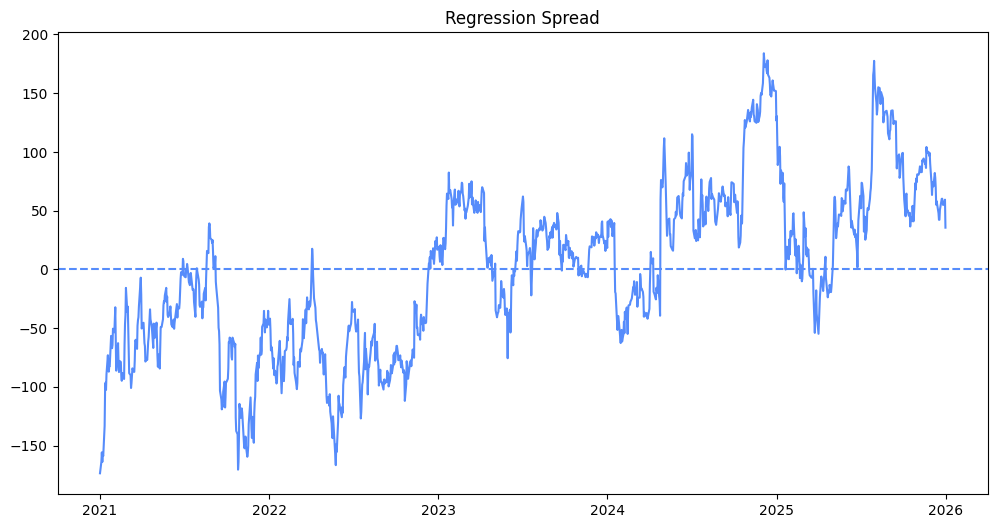

In [6]:
plt.figure(figsize=(12,6))
plt.plot(df['spread_reg'])
plt.axhline(df['spread_reg'].mean(), linestyle='--')
plt.title("Regression Spread")
plt.show()

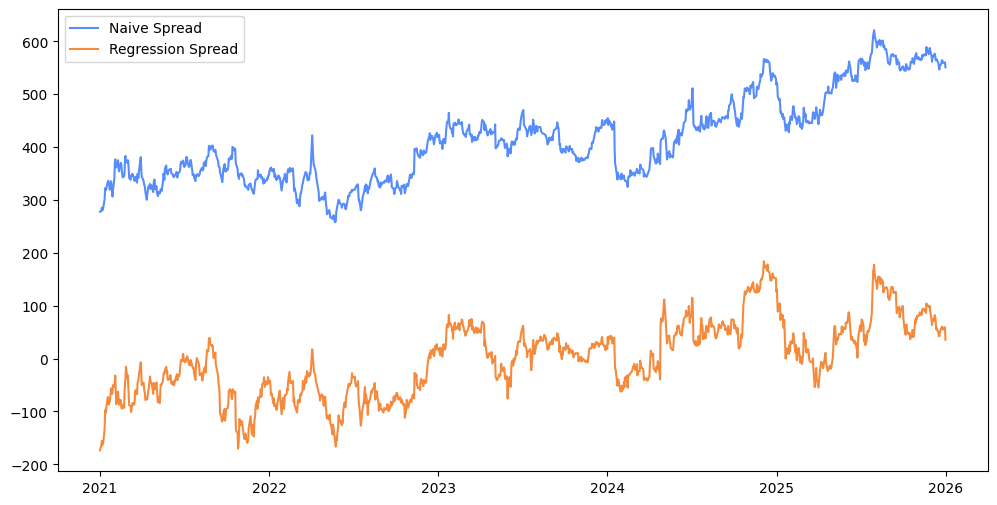

In [7]:
plt.figure(figsize=(12,6))
plt.plot(df['spread'], label='Naive Spread')
plt.plot(df['spread_reg'], label='Regression Spread')
plt.legend()
plt.show()